# Filling factor information patterns

This notebook determines the optical information patterns associated with small center-of-mass displacements of a spherical nanoparticle using incident fields defined through the objective filling factor.

## General imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

## Repository imports and default configuration

In [3]:
import info_patterns.parameters as params
import info_patterns.constants as const
import info_patterns.generate_nanoparticle as gen
import info_patterns.light_matter_interaction_simulation as lmi
import info_patterns.information_patterns_simulation as ips
import info_patterns.plots as plots
plots.set_plot_style(usetex=params.DEFAULT_USETEX, font_family=params.DEFAULT_FONT_FAMILY, figsize=params.DEFAULT_FIGSIZE) # Apply the default plotting style used across the repository 

## Nanoparticle geometry and material

In [4]:
geometry = gen.nanoparticle_geometry(**params.SPHERE_GEOMETRY_PARAMS) # Generate the discretized nanoparticle geometry 
material = gen.nanoparticle_material(params.DEFAULT_MATERIAL_NAME, **params.DEFAULT_MATERIAL_KWARGS) # Load the optical material model used by pyGDM

## Optical setup and electromagnetic propagator

In [5]:
# Far-field angular sampling parameters
farfield_params = params.FAST_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
r = farfield_params["r"]
field_index = farfield_params["field_index"]

# Simulator parameters
step_nm = params.SPHERE_GEOMETRY_PARAMS["step_nm"]
disp_nm = params.DEFAULT_COM_DISPLACEMENT_NM
wavelength_nm = params.DEFAULT_WAVELENGTH_NM

NA = params.DEFAULT_VECTOR_BEAM_NA
f_mm = params.DEFAULT_VECTOR_BEAM_F_MM
gamma = params.DEFAULT_FILLING_FACTOR

optical_power_W = params.DEFAULT_OPTICAL_POWER_W
impedance_ohm = params.DEFAULT_FREE_SPACE_IMPEDANCE_OHM

print("Global optical parameters")
print("wavelength =", wavelength_nm, "nm")
print("NA =", NA)
print("f =", f_mm, "mm")
print("gamma =", gamma)
print("optical power =", optical_power_W, "W")
print("impedance =", impedance_ohm, "Ohm")

dyads = lmi.field_propagation(**params.DEFAULT_DYADS_PARAMS) # Electromagnetic propagator/dyadic Green tensor configuration

Global optical parameters
wavelength = 1550.0 nm
NA = 0.8
f = 3.0 mm
gamma = 1.0
optical power = 0.001 W
impedance = 377.0 Ohm


## Hermite-Gauss incident field

In this cell, we build the `HermiteGauss00` incident field using the filling factor.

The function `w0_from_filling_factor` converts the filling factor into the beam waist `w0`. The function `hermite_gauss00_power_amplitude_factor` sets the field amplitude from the optical power and free-space impedance.

The resulting object `hermite_efield` is then passed to pyGDM as the incident optical field.

In [6]:
hermite_params = params.DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS.copy()
hermite_params["w0"] = lmi.w0_from_filling_factor(gamma=gamma, NA=hermite_params["NA"], f_mm=hermite_params["f"])
hermite_amplitude = lmi.hermite_gauss00_power_amplitude_factor(optical_power_W=optical_power_W, w0_mm=hermite_params["w0"], impedance_ohm=impedance_ohm)

# HermiteGauss00 requires exactly one of theta or polarization_state.
# Since we want to include the physical amplitude, use polarization_state
# and explicitly disable theta.
hermite_params["theta"] = None
hermite_params["polarization_state"] = (hermite_amplitude, 0.0, 0.0, 0.0)

print("Incident field: HermiteGauss00")
print("gamma =", gamma)
print("NA =", hermite_params["NA"])
print("f =", hermite_params["f"], "mm")
print("w0 =", hermite_params["w0"], "mm")
print("optical power =", optical_power_W, "W")
print("amplitude factor =", hermite_amplitude)
print("normalize =", hermite_params["normalize"])
print("theta =", hermite_params["theta"])
print("polarization_state =", hermite_params["polarization_state"])

hermite_efield = lmi.incident_field(**hermite_params)

Incident field: HermiteGauss00
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm
optical power = 0.001 W
amplitude factor = 10.000117794776598
normalize = False
theta = None
polarization_state = (10.000117794776598, 0.0, 0.0, 0.0)


## COM displacement along x for the Hermite-Gauss field

In [7]:
E_plus_x, E_minus_x, dE_x = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=hermite_efield, dyads=dyads, axis_index=0, disp_nm=disp_nm, **farfield_params)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = ips.info_patterns_from_scattered_field(dE=dE_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 1799.3ms, inv.: 267.5ms, repropa.: 5497.3ms (1 field configs), tot: 7564.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 43.4ms, inv.: 298.2ms, repropa.: 4512.1ms (1 field configs), tot: 4853.9ms


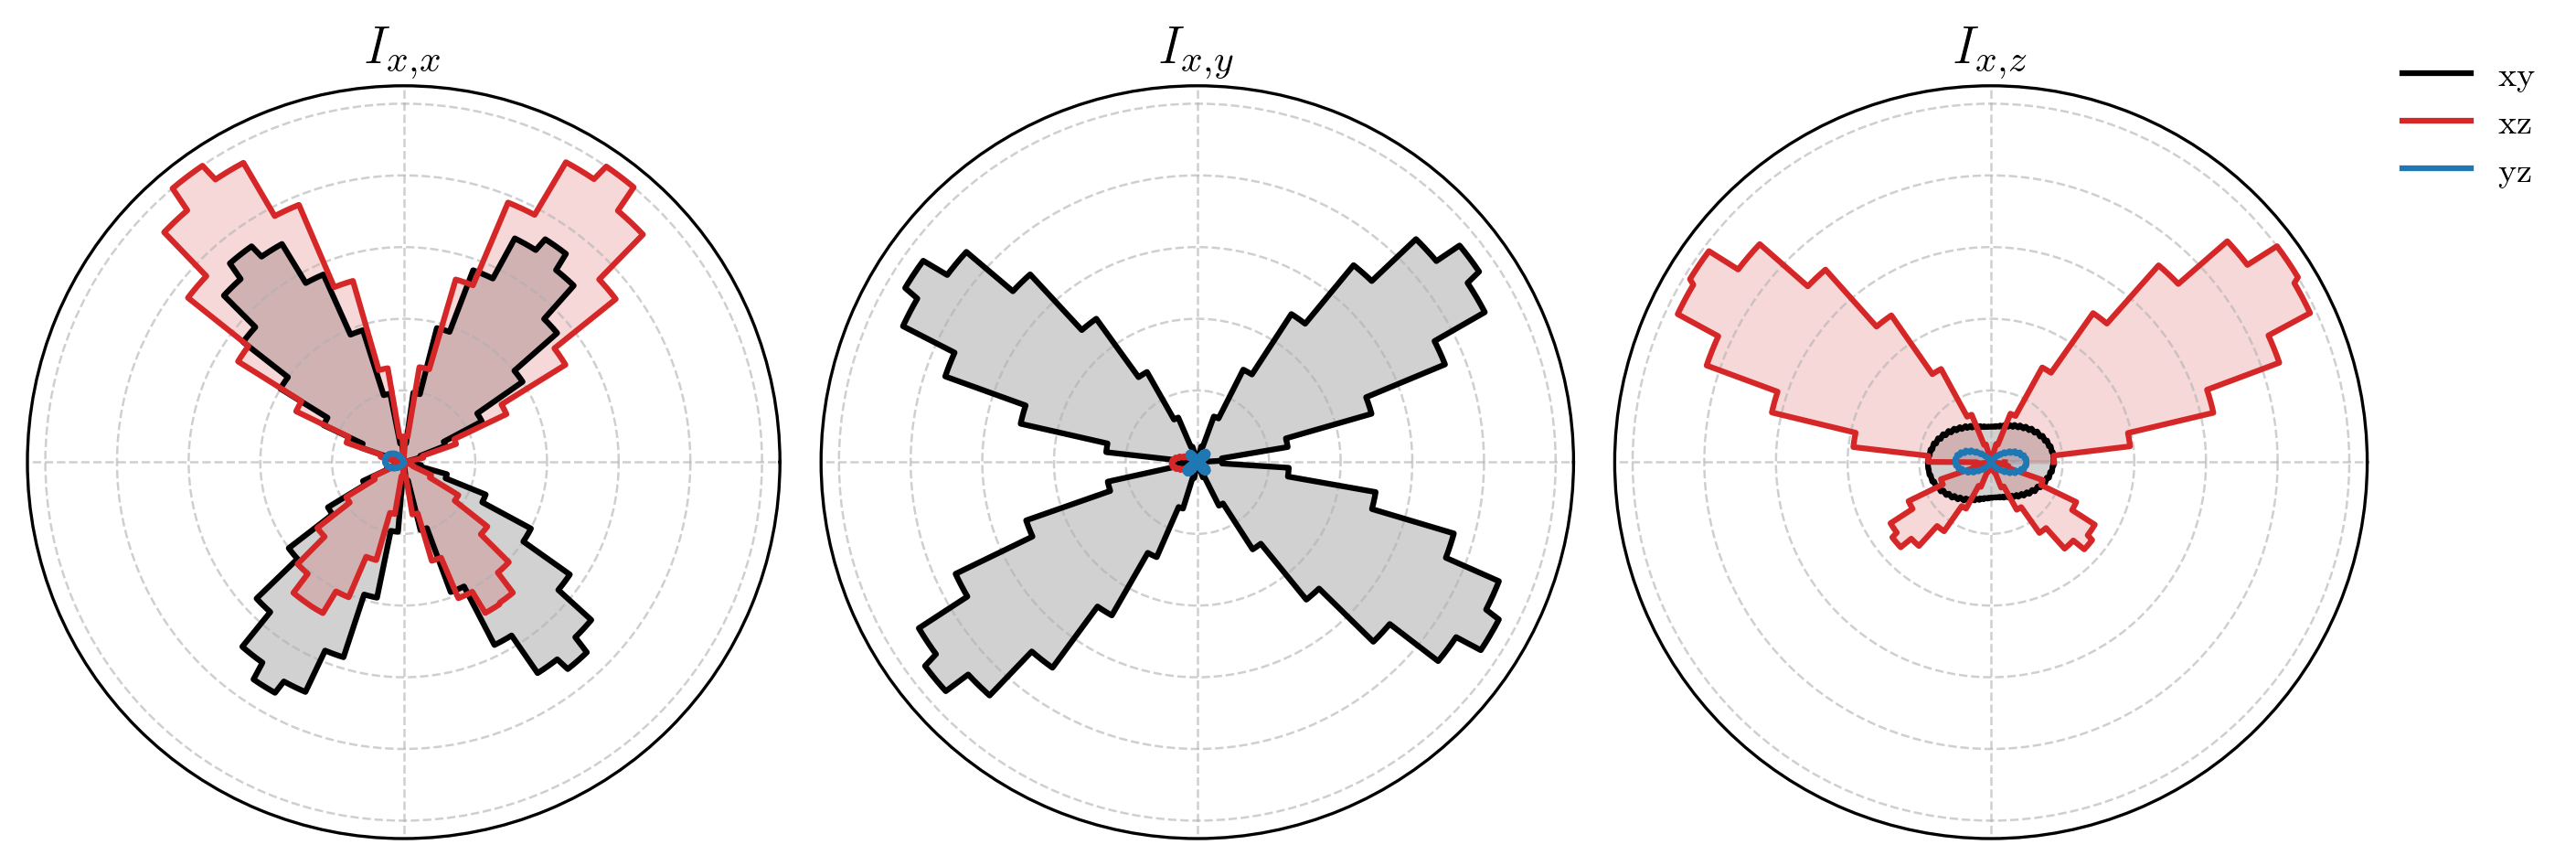

In [8]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"])

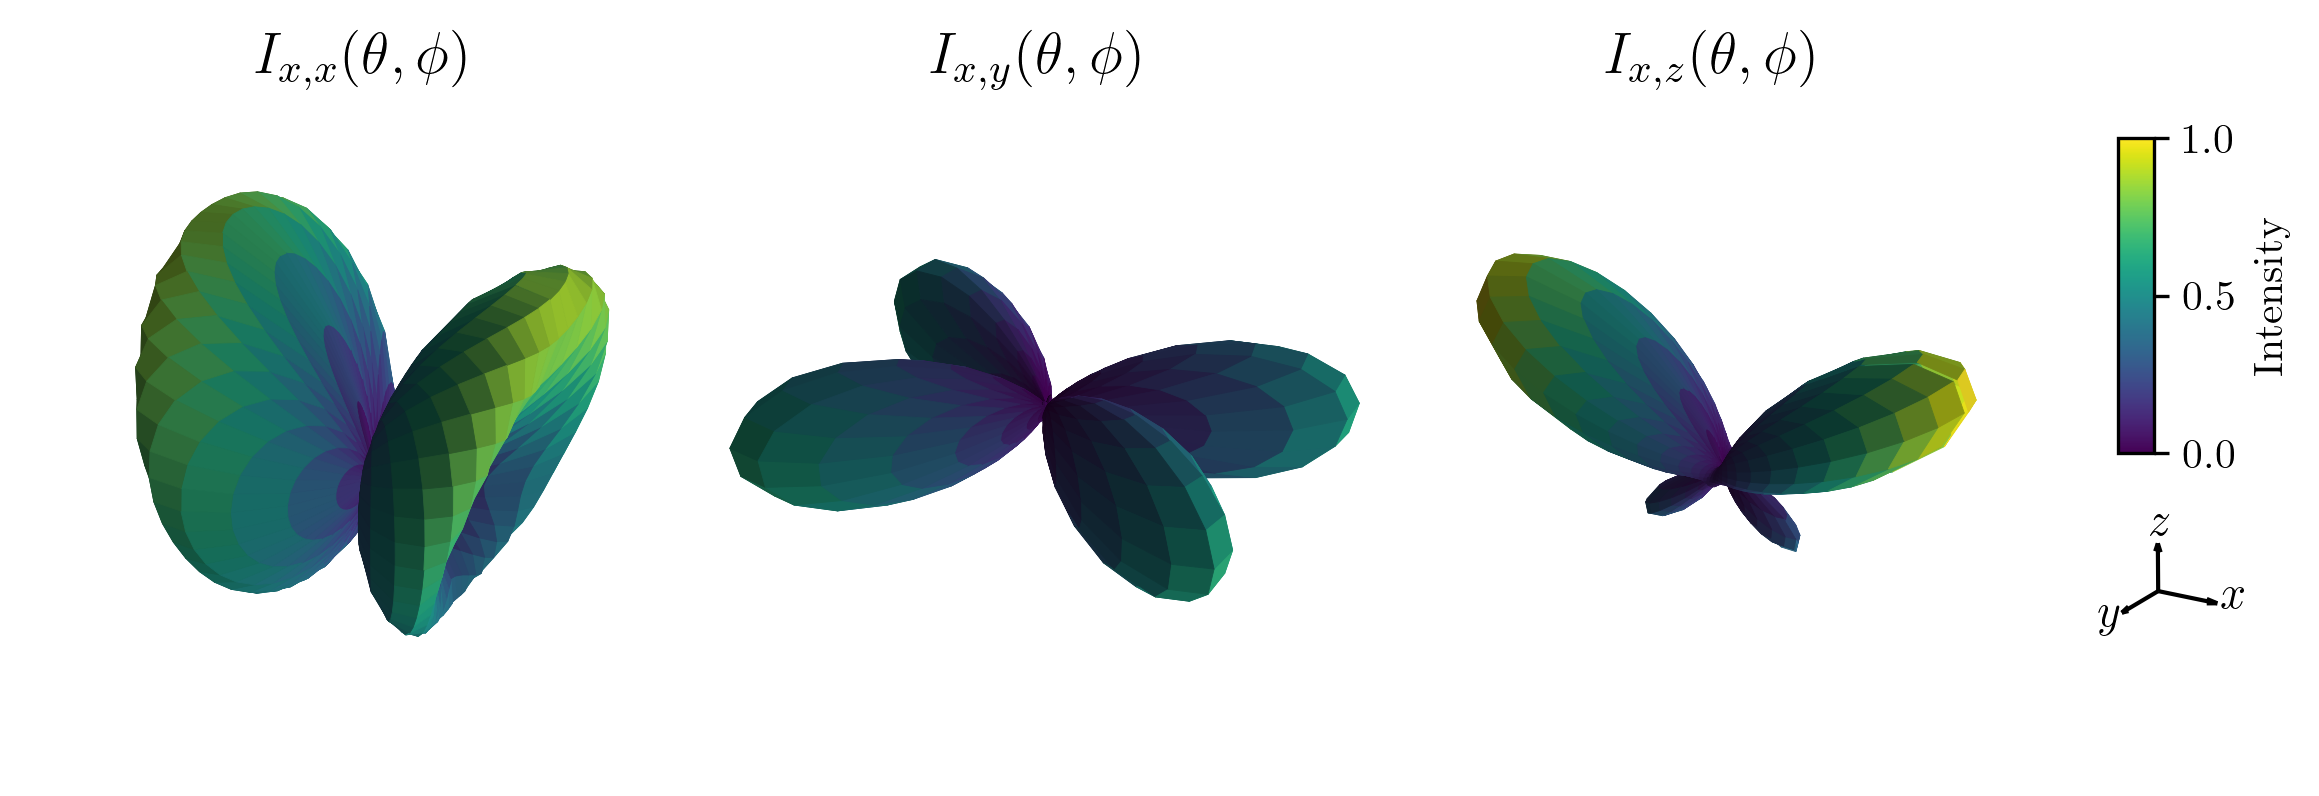

In [9]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], scale_list=[0.42, 0.32, 0.32])

## COM displacement along y for the Hermite-Gauss field

In [10]:
E_plus_y, E_minus_y, dE_y = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=hermite_efield, dyads=dyads, axis_index=1, disp_nm=disp_nm, **farfield_params)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = ips.info_patterns_from_scattered_field(dE=dE_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 90.4ms, inv.: 251.2ms, repropa.: 5523.8ms (1 field configs), tot: 5865.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 52.3ms, inv.: 239.6ms, repropa.: 4176.3ms (1 field configs), tot: 4468.4ms


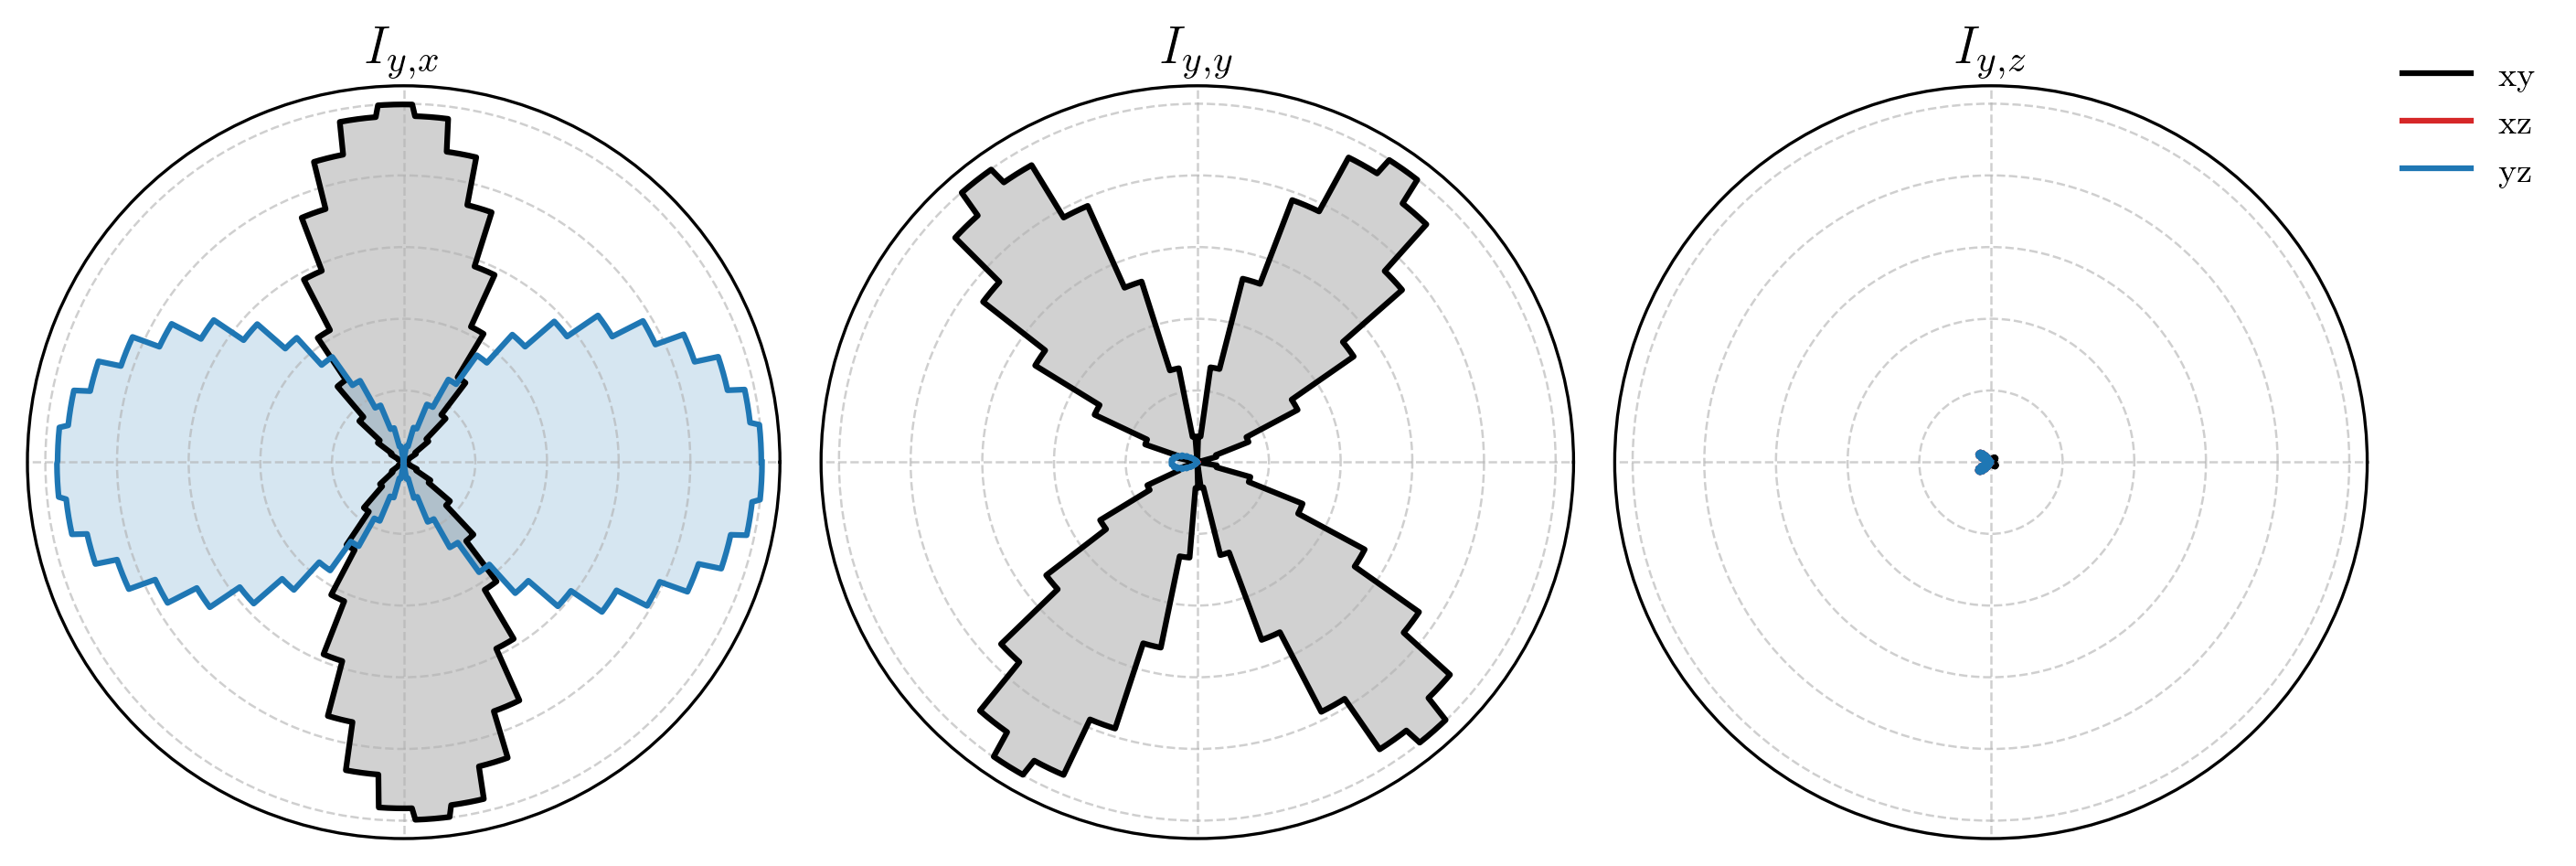

In [11]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"])

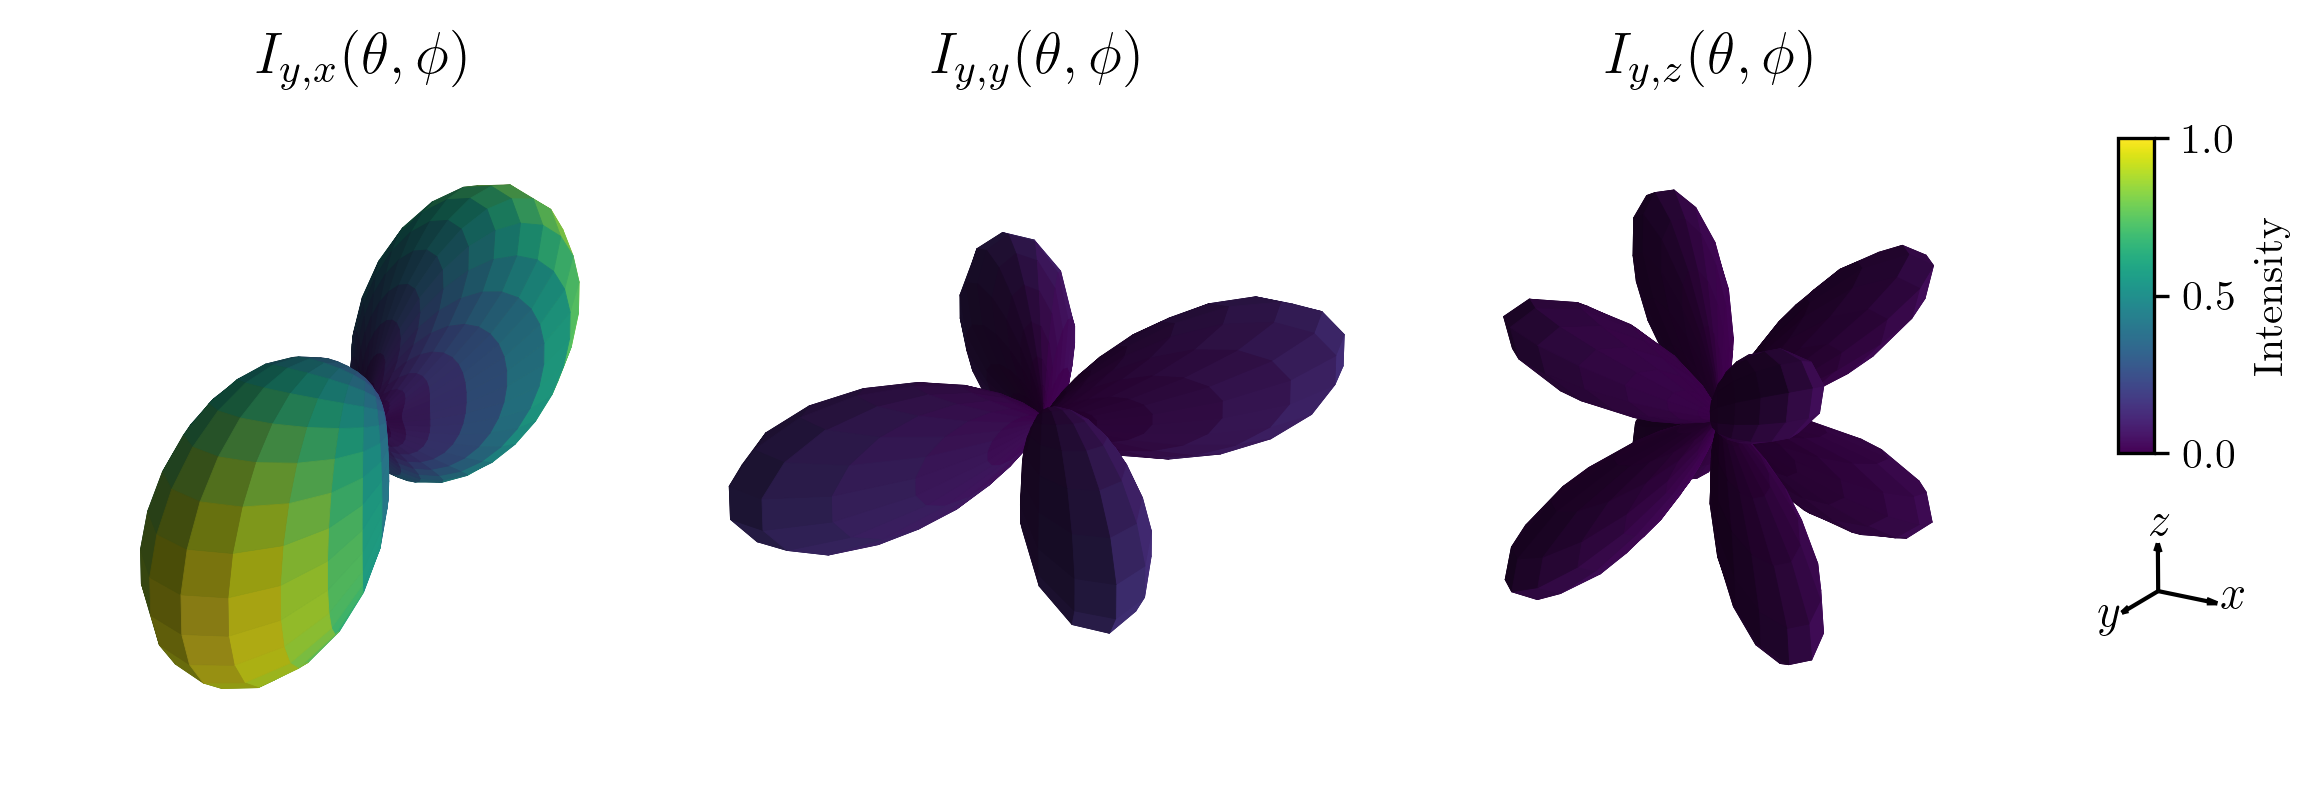

In [12]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], scale_list=[0.22, 0.30, 0.49])

## COM displacement along z for the Hermite-Gauss field

In [13]:
E_plus_z, E_minus_z, dE_z = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=hermite_efield, dyads=dyads, axis_index=2, disp_nm=disp_nm, **farfield_params)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = ips.info_patterns_from_scattered_field(dE=dE_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 64.0ms, inv.: 255.2ms, repropa.: 4900.7ms (1 field configs), tot: 5220.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 57.0ms, inv.: 349.5ms, repropa.: 5197.2ms (1 field configs), tot: 5603.8ms


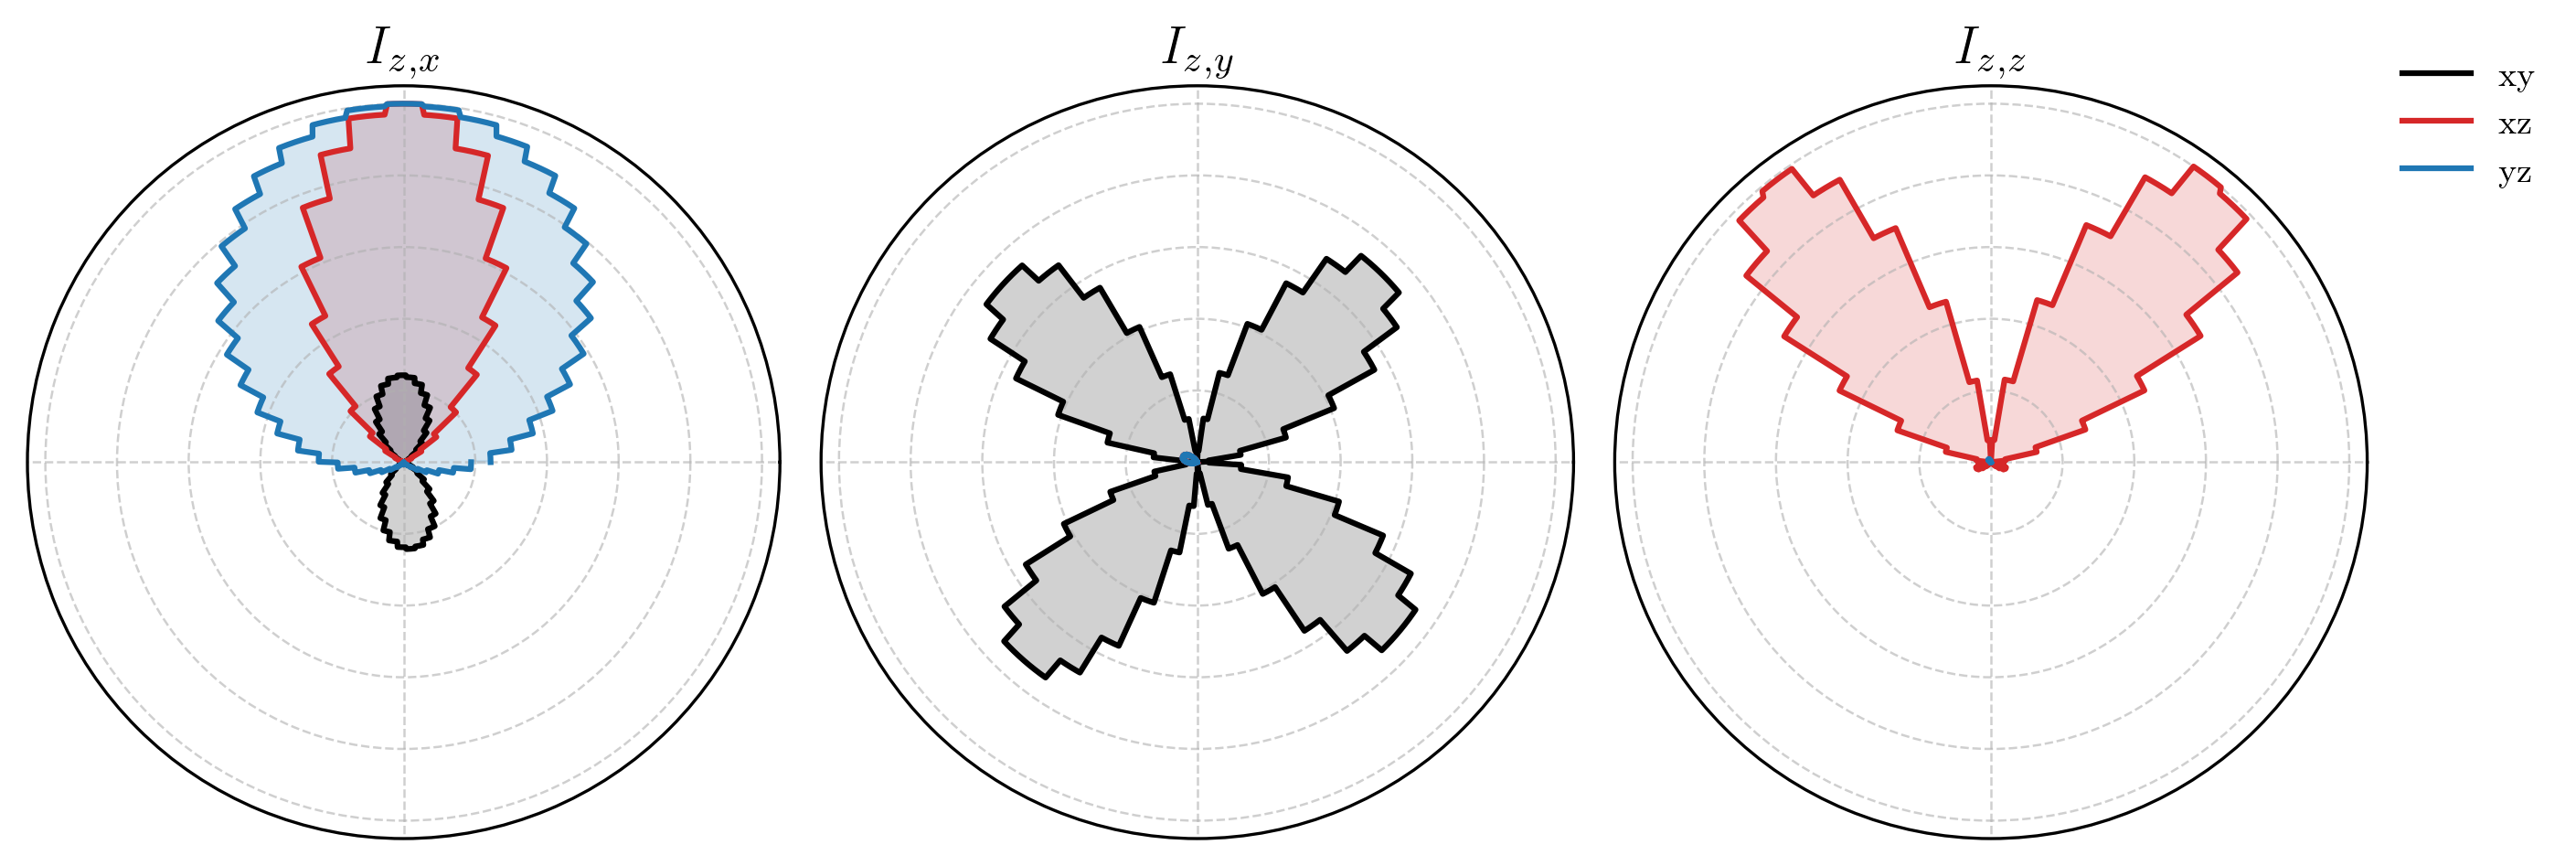

In [14]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"])

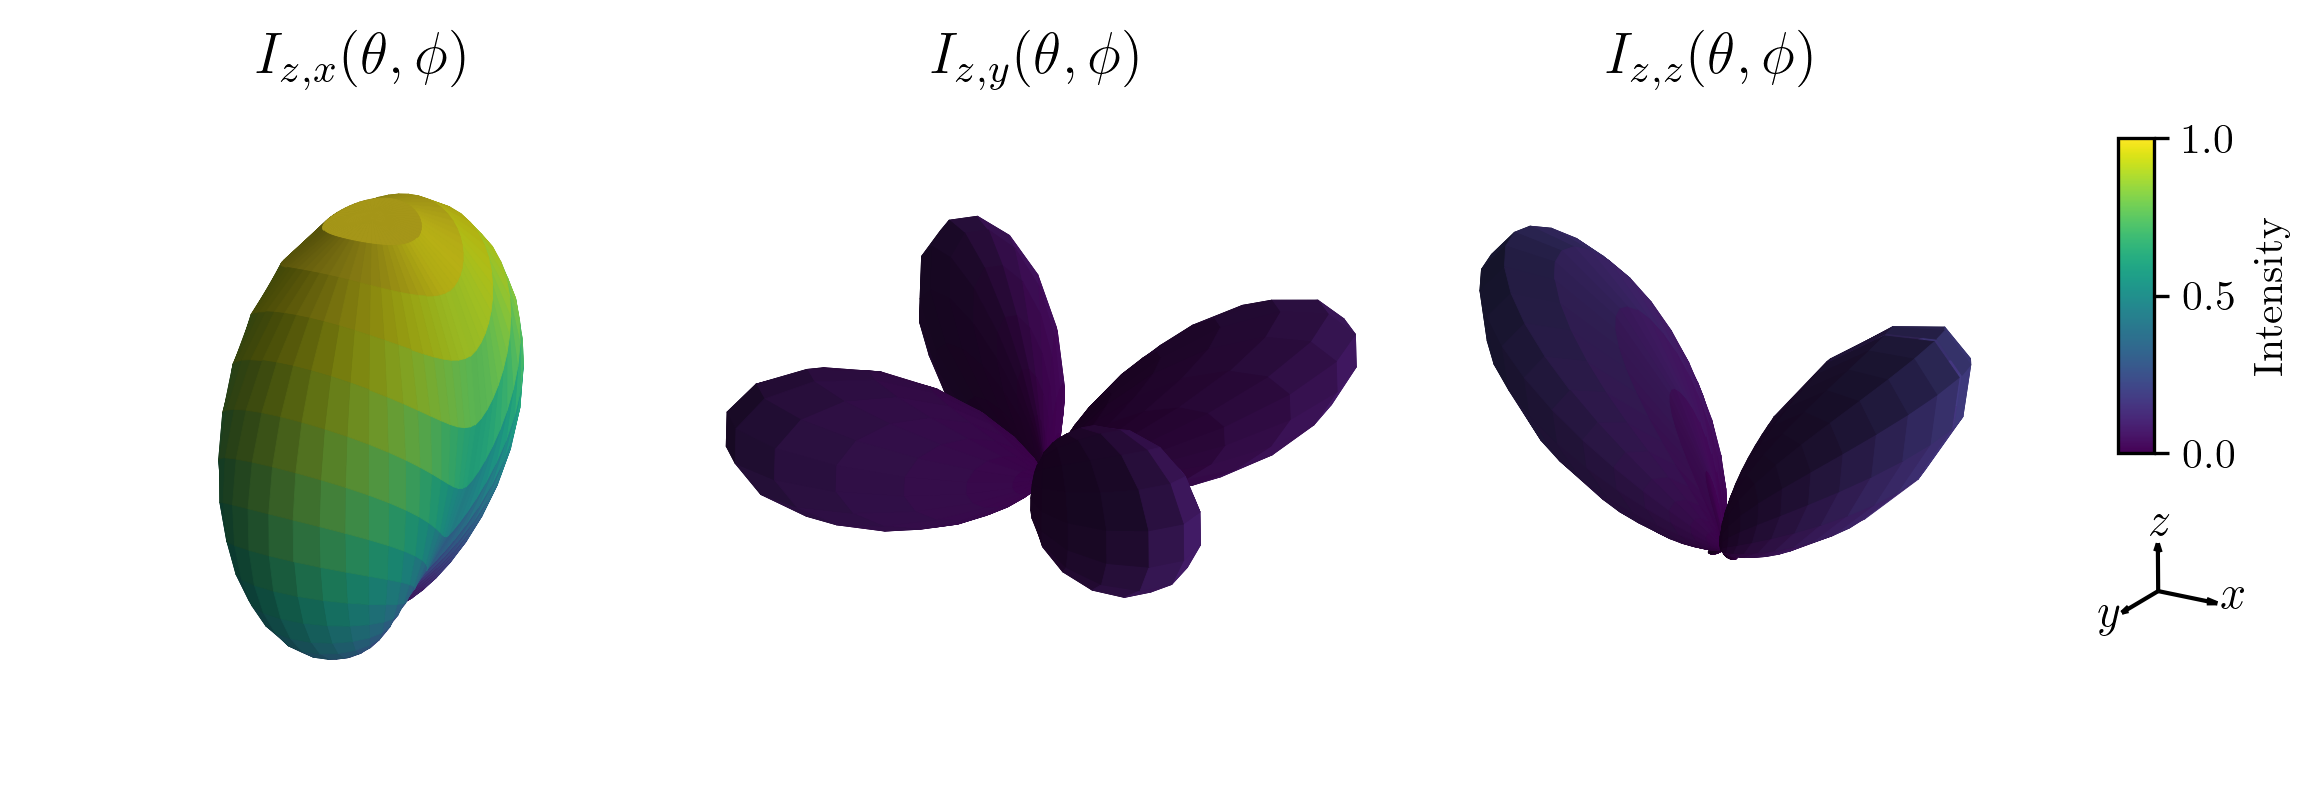

In [15]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], scale_list=[0.38, 0.34, 0.33])

## Total COM information patterns for the Hermite-Gauss field

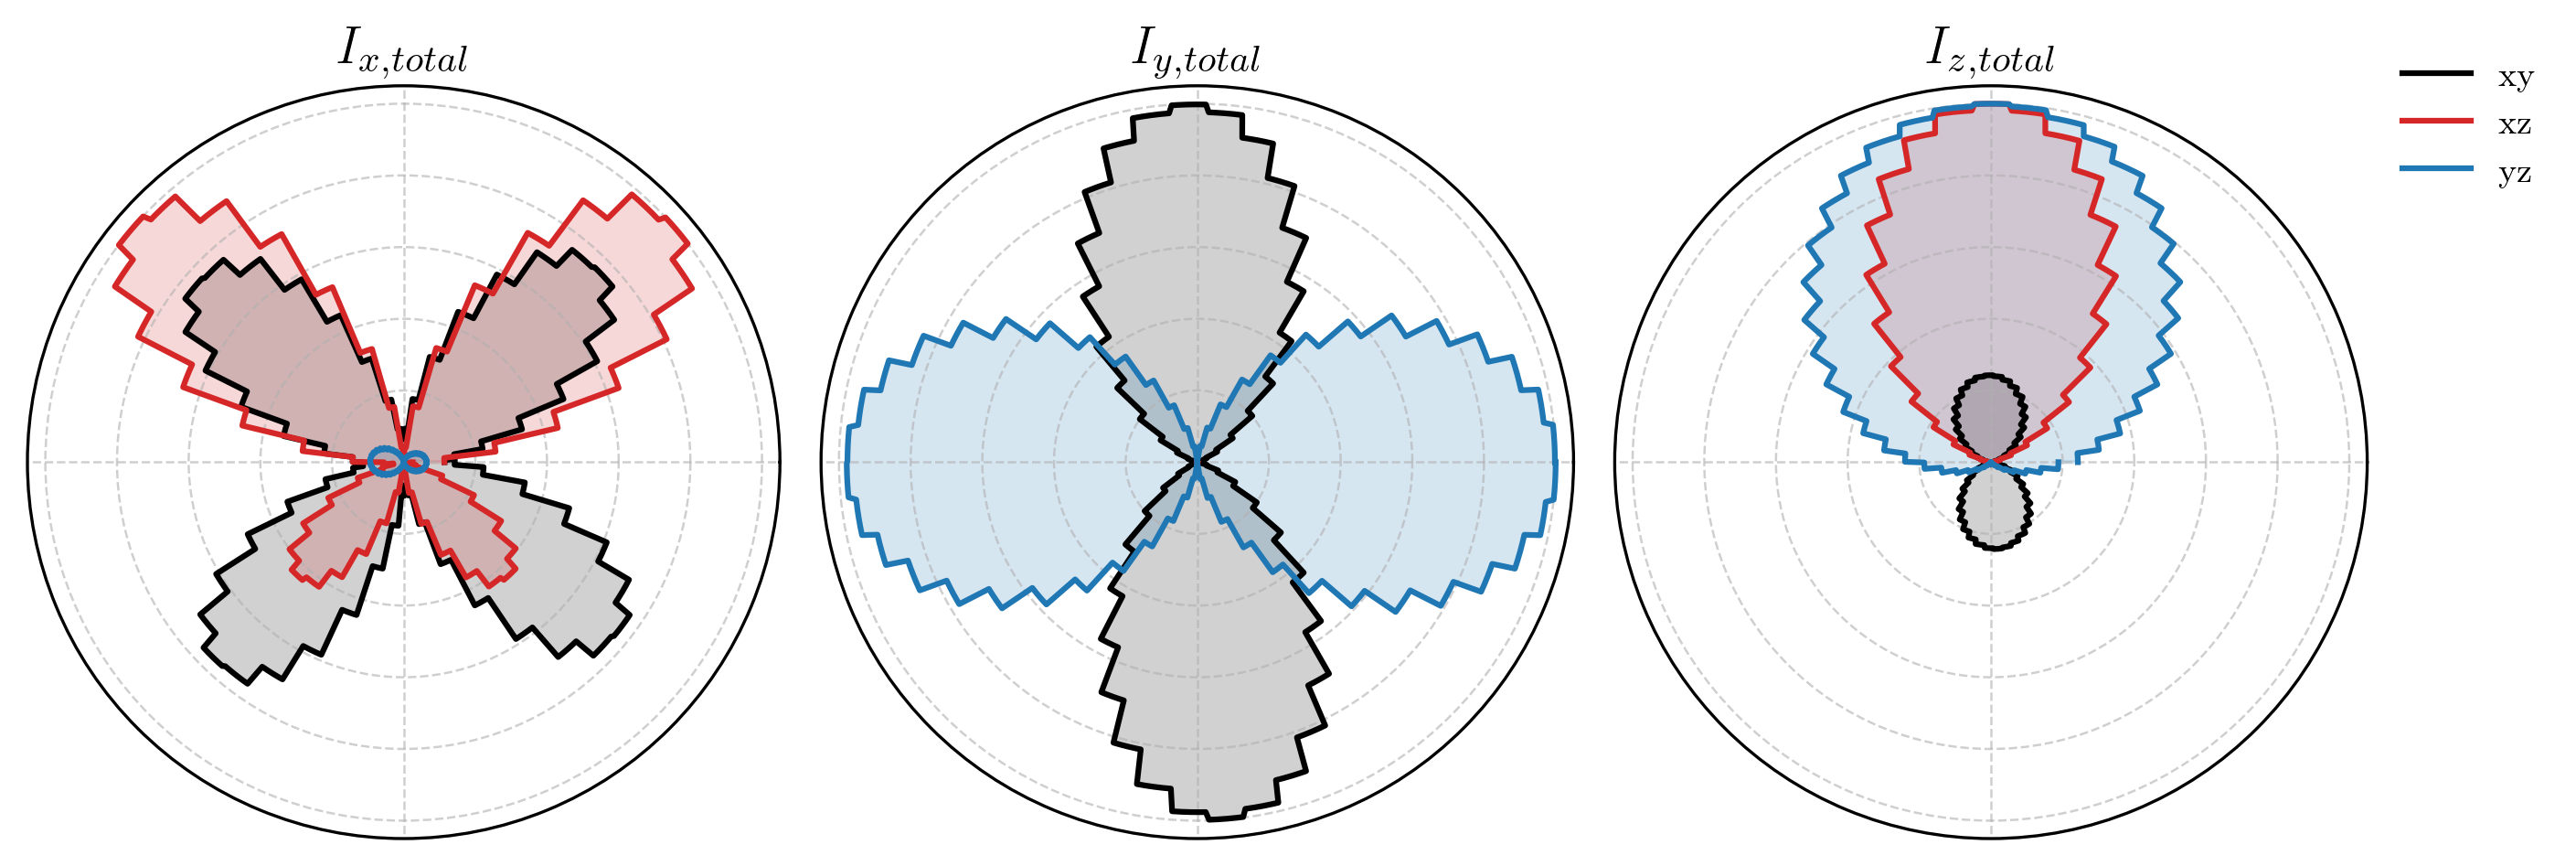

In [16]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"])

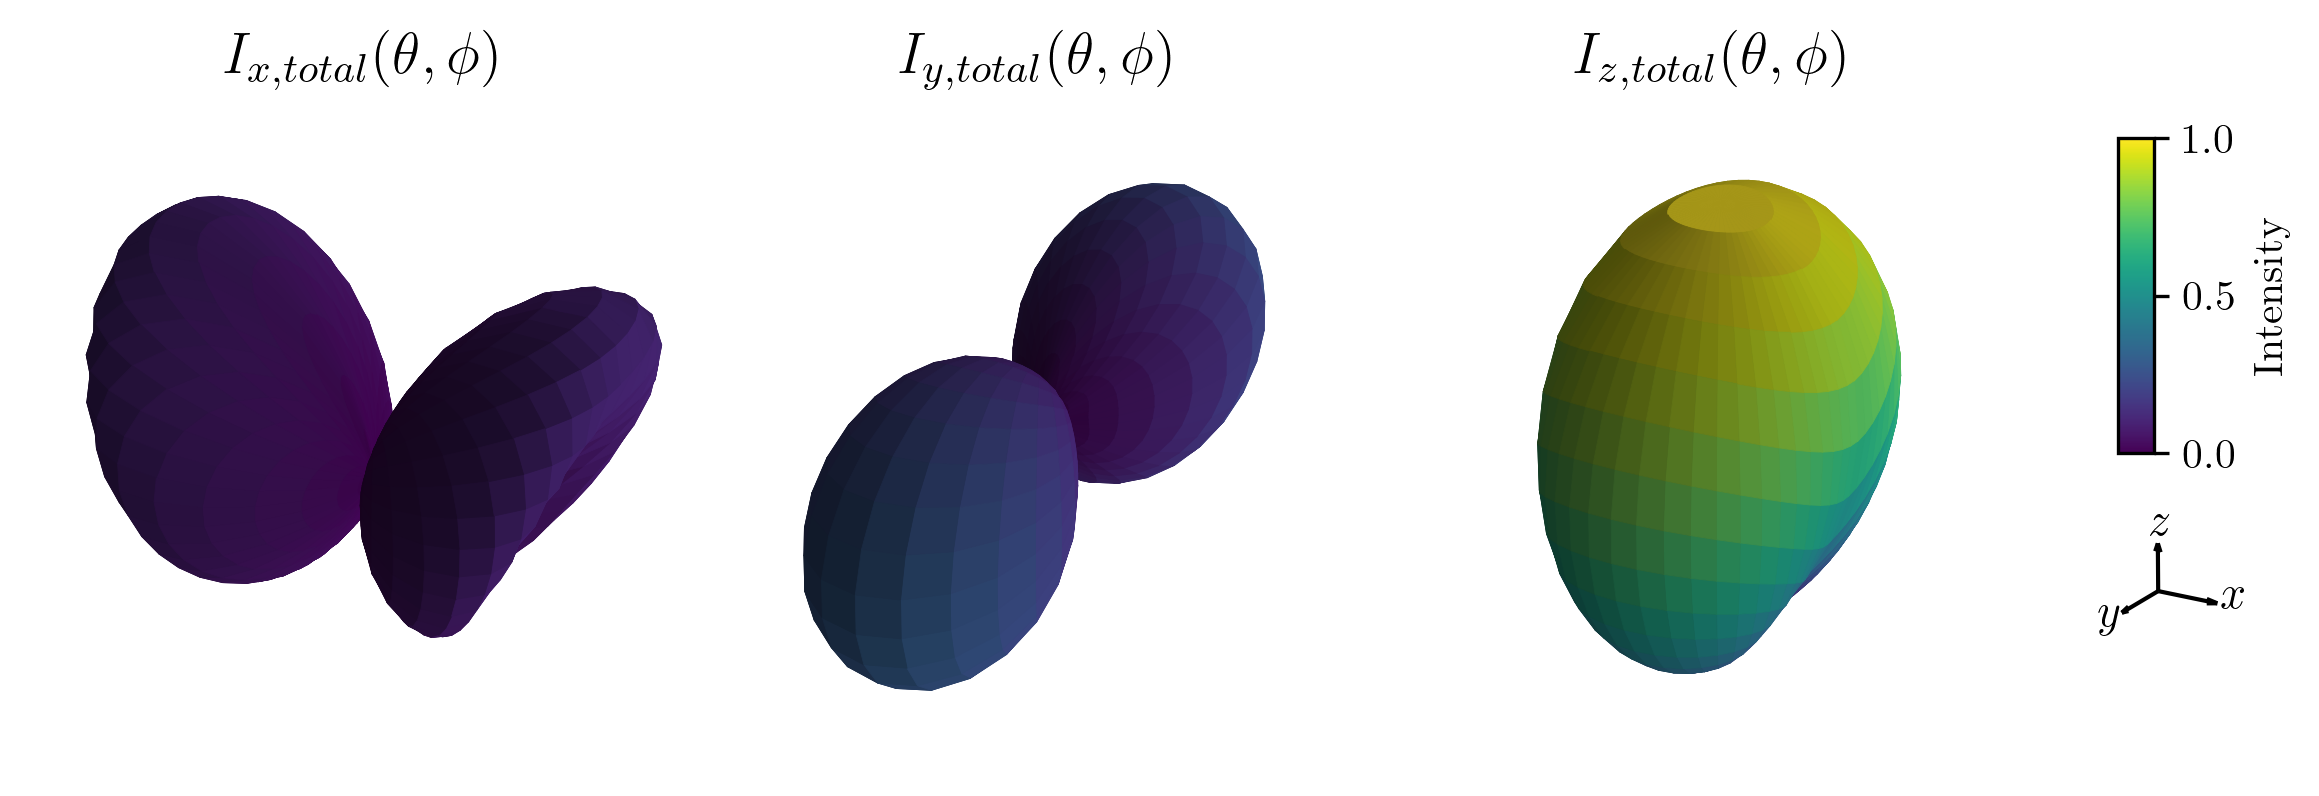

In [17]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], scale_list=[0.32, 0.22, 0.36])

## Radial doughnut incident field

Now, we build the `Radial_pol_doughnut` incident field using the same filling factor.

In [18]:
radial_params = params.DEFAULT_RADIAL_DOUGHNUT_FIELD_PARAMS.copy()
radial_params["w0"] = lmi.w0_from_filling_factor(gamma=gamma, NA=radial_params["NA"], f_mm=radial_params["f"])

print("Radial_pol_doughnut")
print("gamma =", gamma)
print("NA =", radial_params["NA"])
print("f =", radial_params["f"], "mm")
print("w0 =", radial_params["w0"], "mm")

radial_efield = lmi.incident_field(**radial_params)

Radial_pol_doughnut
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm


## COM displacement along x for the radial doughnut field

In [19]:
E_plus_x, E_minus_x, dE_x = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=radial_efield, dyads=dyads, axis_index=0, disp_nm=disp_nm, **farfield_params)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = ips.info_patterns_from_scattered_field(dE=dE_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 83.4ms, inv.: 361.7ms, repropa.: 6402.8ms (1 field configs), tot: 6848.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 45.2ms, inv.: 259.0ms, repropa.: 4951.1ms (1 field configs), tot: 5255.5ms


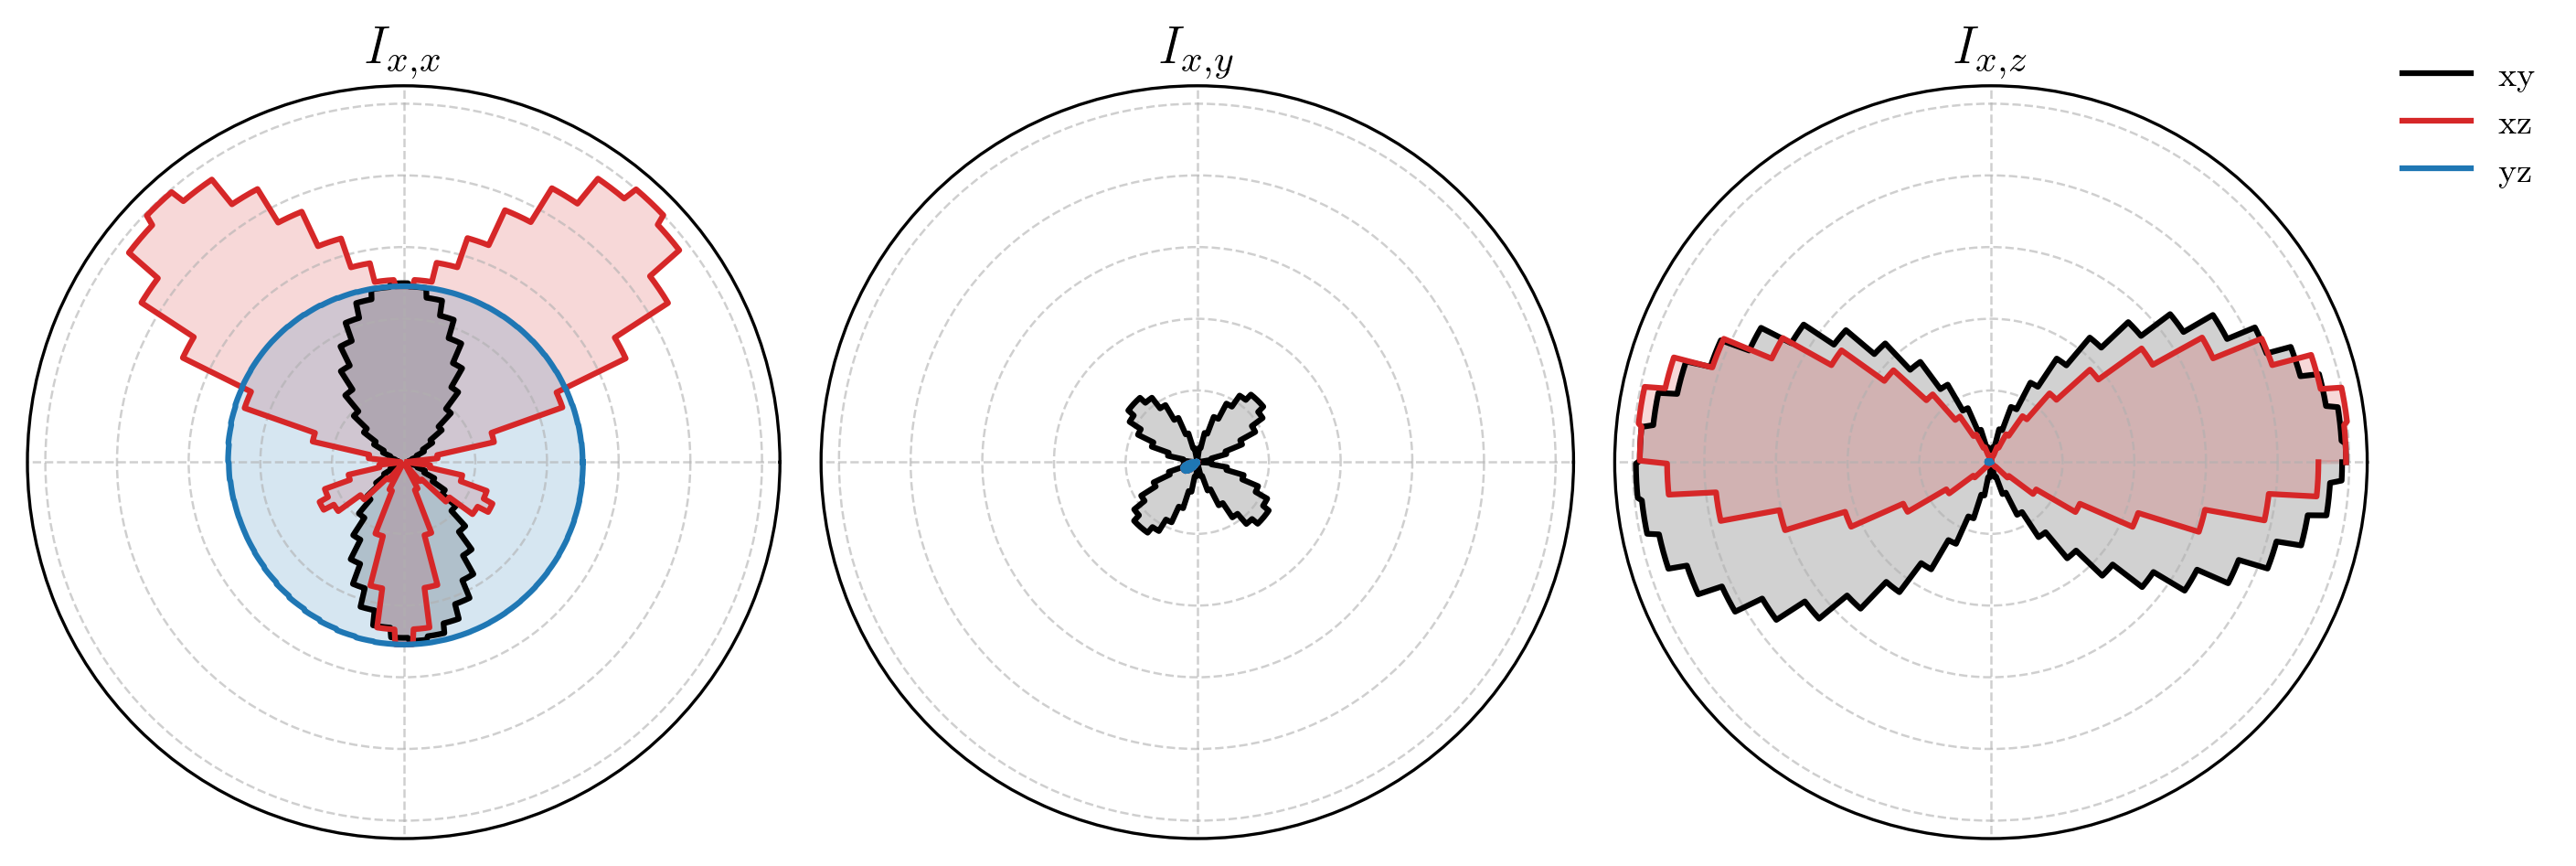

In [20]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"])

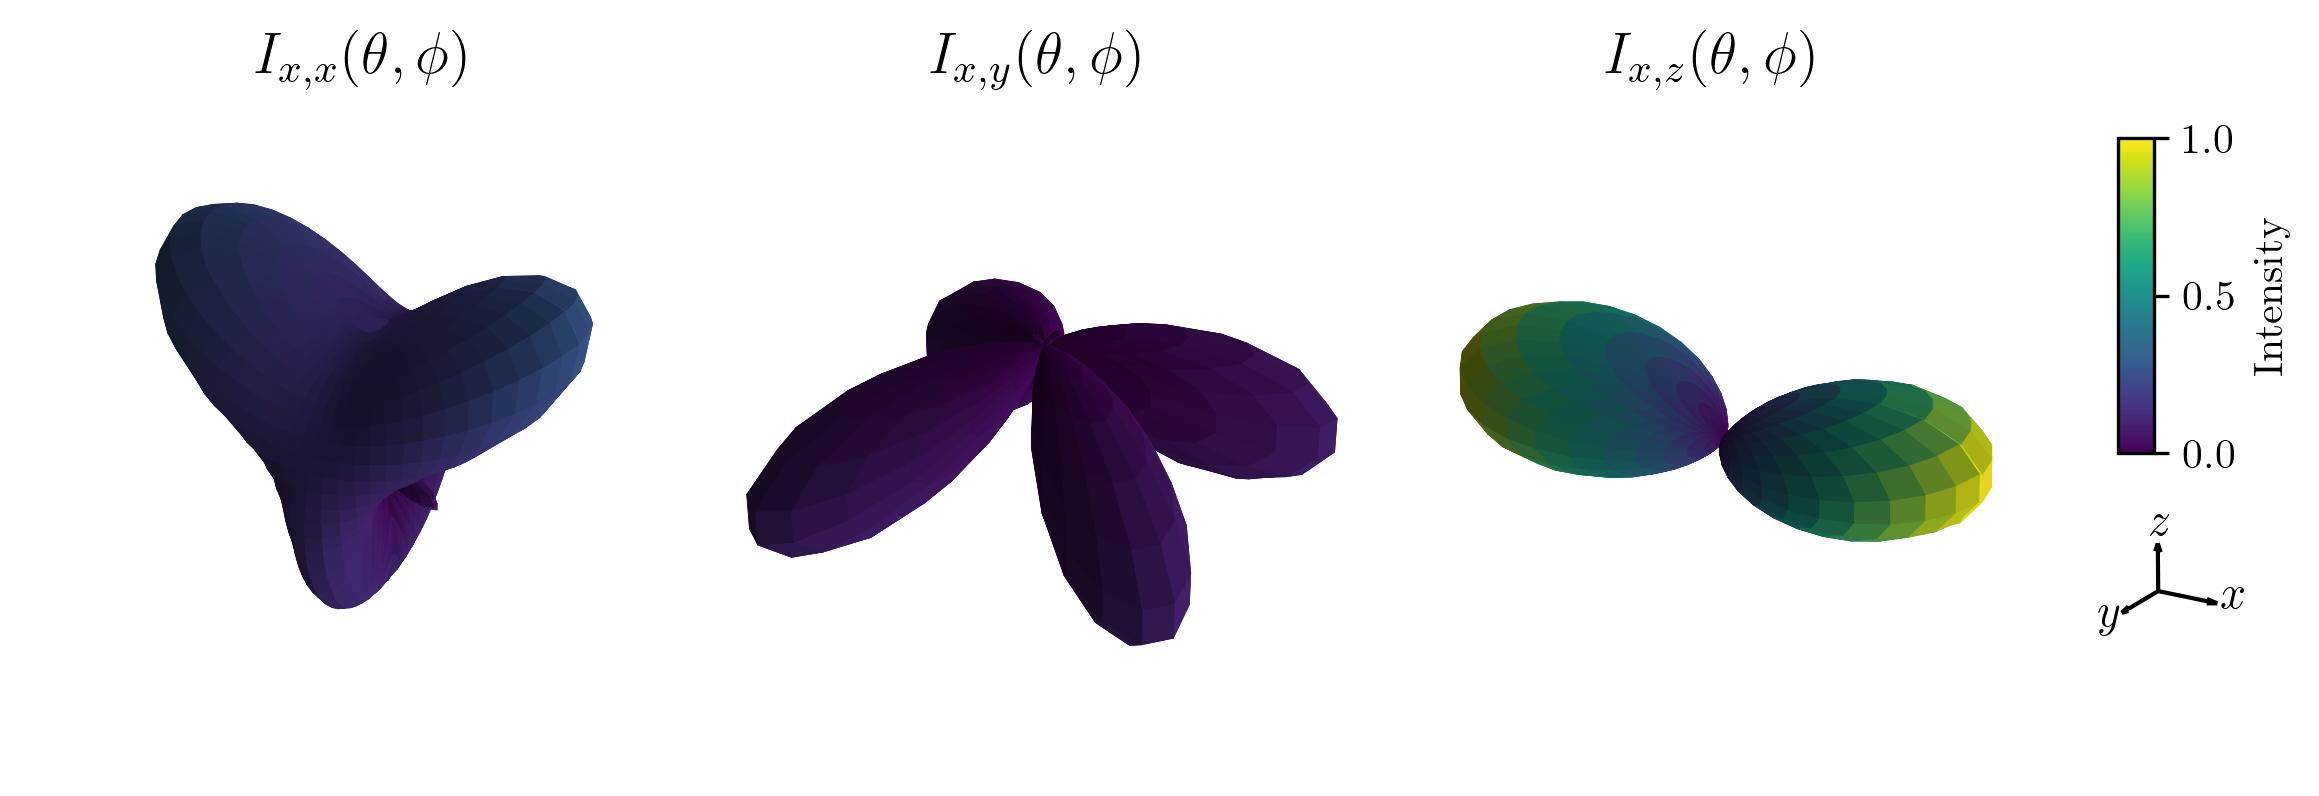

In [21]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], scale_list=[0.38, 0.36, 0.3])

## COM displacement along y for the radial doughnut field

In [22]:
E_plus_y, E_minus_y, dE_y = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=radial_efield, dyads=dyads, axis_index=1, disp_nm=disp_nm, **farfield_params)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = ips.info_patterns_from_scattered_field(dE=dE_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 64.9ms, inv.: 262.6ms, repropa.: 4741.4ms (1 field configs), tot: 5068.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 45.2ms, inv.: 247.8ms, repropa.: 5148.5ms (1 field configs), tot: 5441.7ms


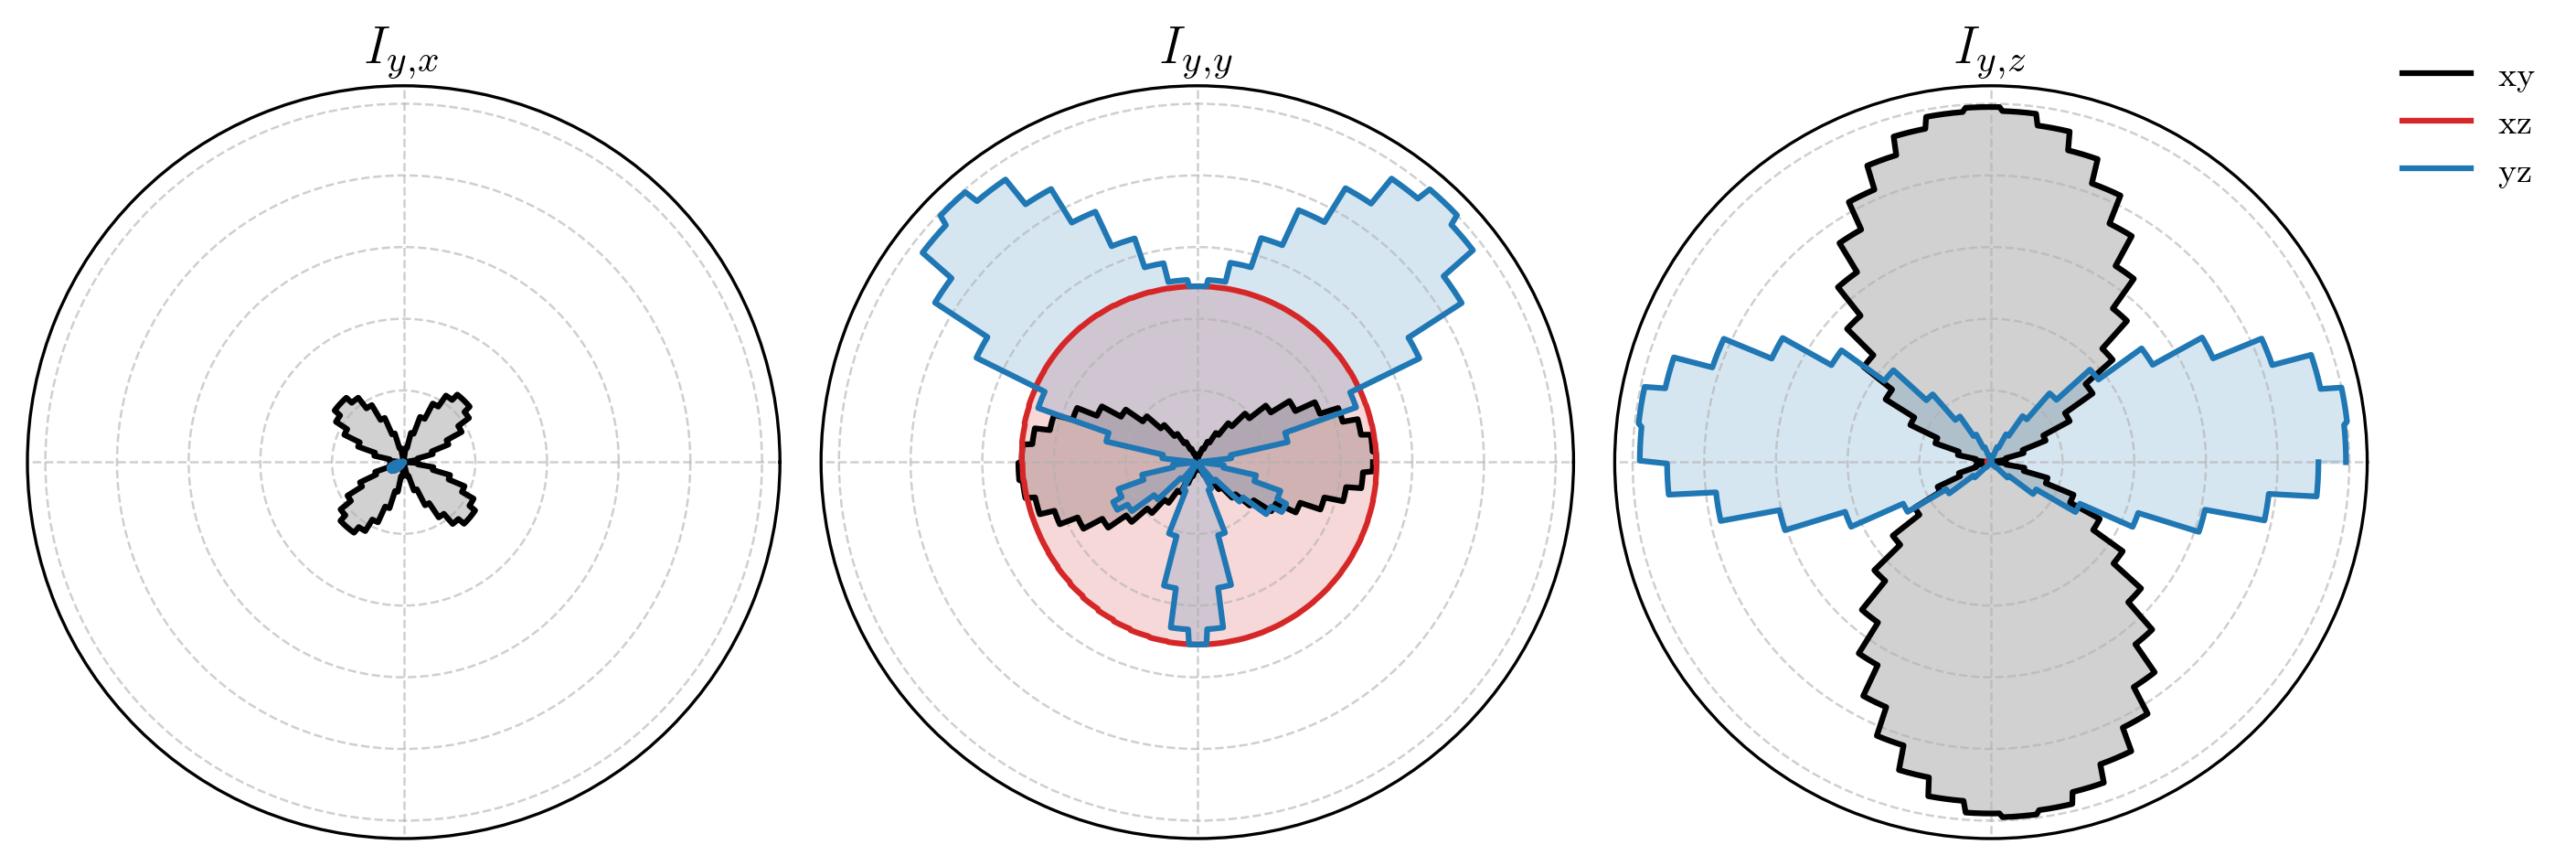

In [23]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"])

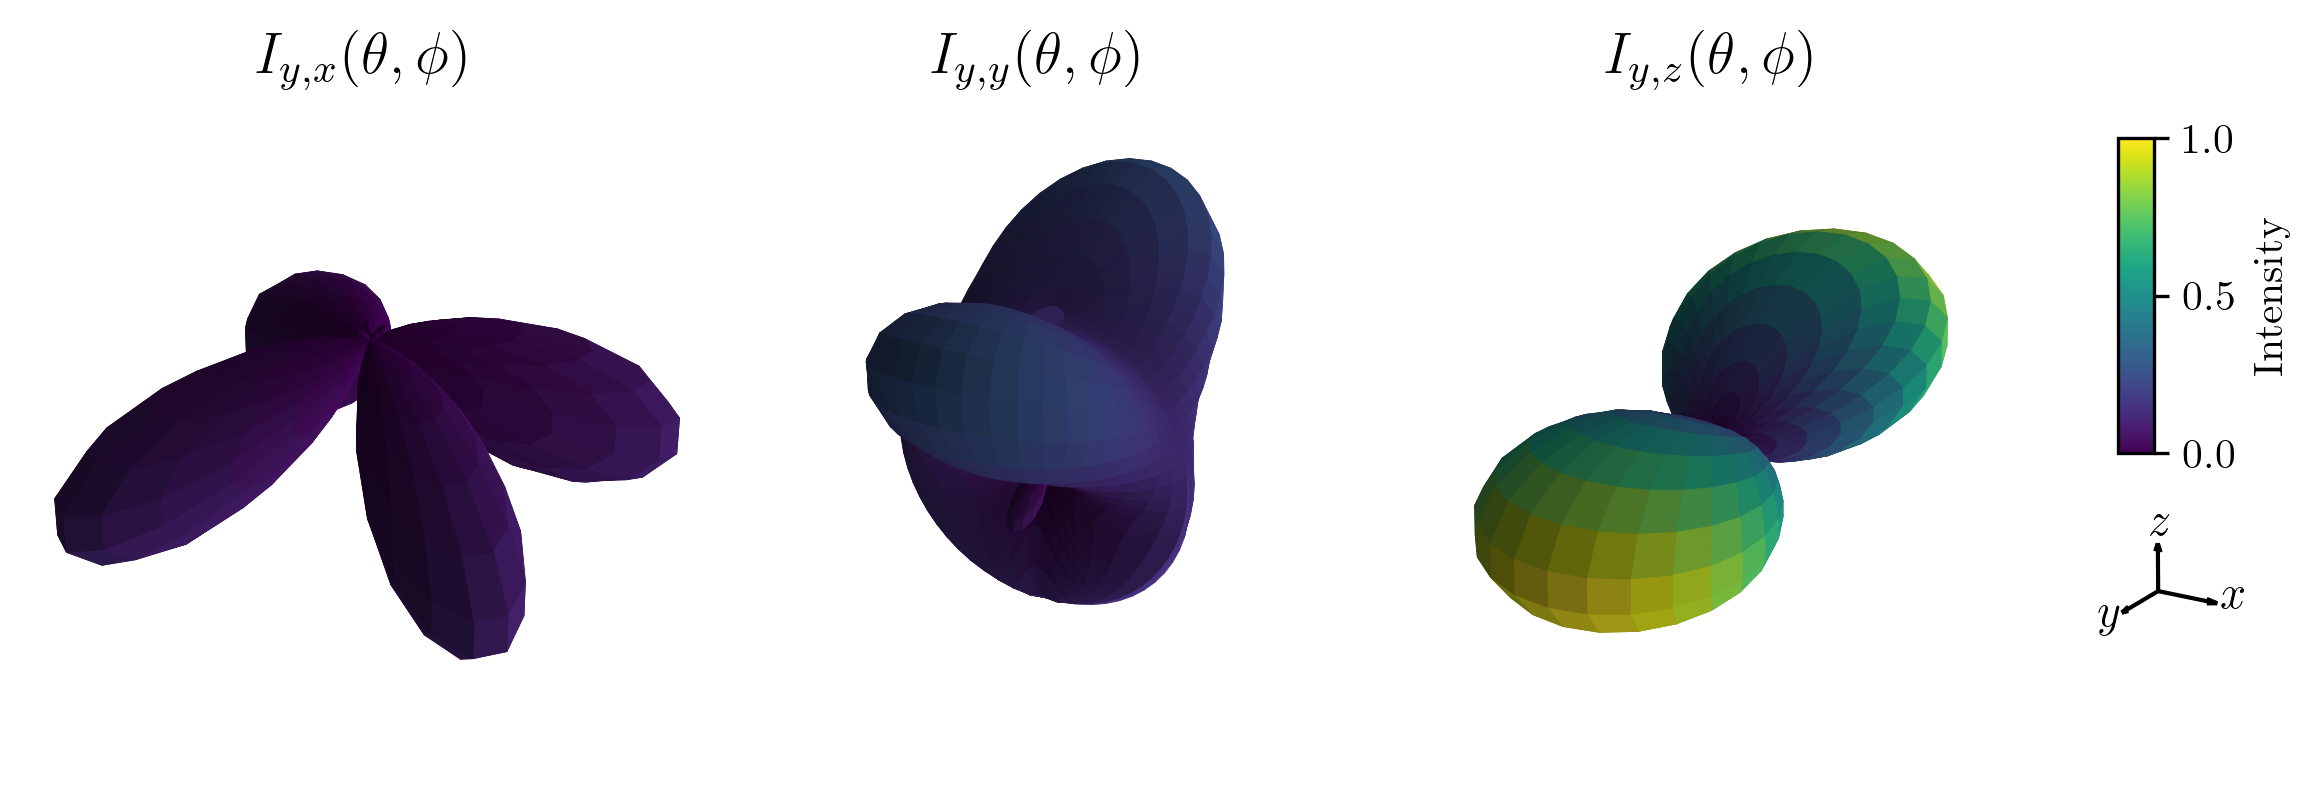

In [24]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], scale_list=[0.34, 0.36, 0.24])

## COM displacement along z for the radial doughnut field

In [25]:
E_plus_z, E_minus_z, dE_z = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=radial_efield, dyads=dyads, axis_index=2, disp_nm=disp_nm, **farfield_params)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = ips.info_patterns_from_scattered_field(dE=dE_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 82.2ms, inv.: 284.8ms, repropa.: 4818.4ms (1 field configs), tot: 5185.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 45.9ms, inv.: 258.4ms, repropa.: 6028.9ms (1 field configs), tot: 6333.4ms


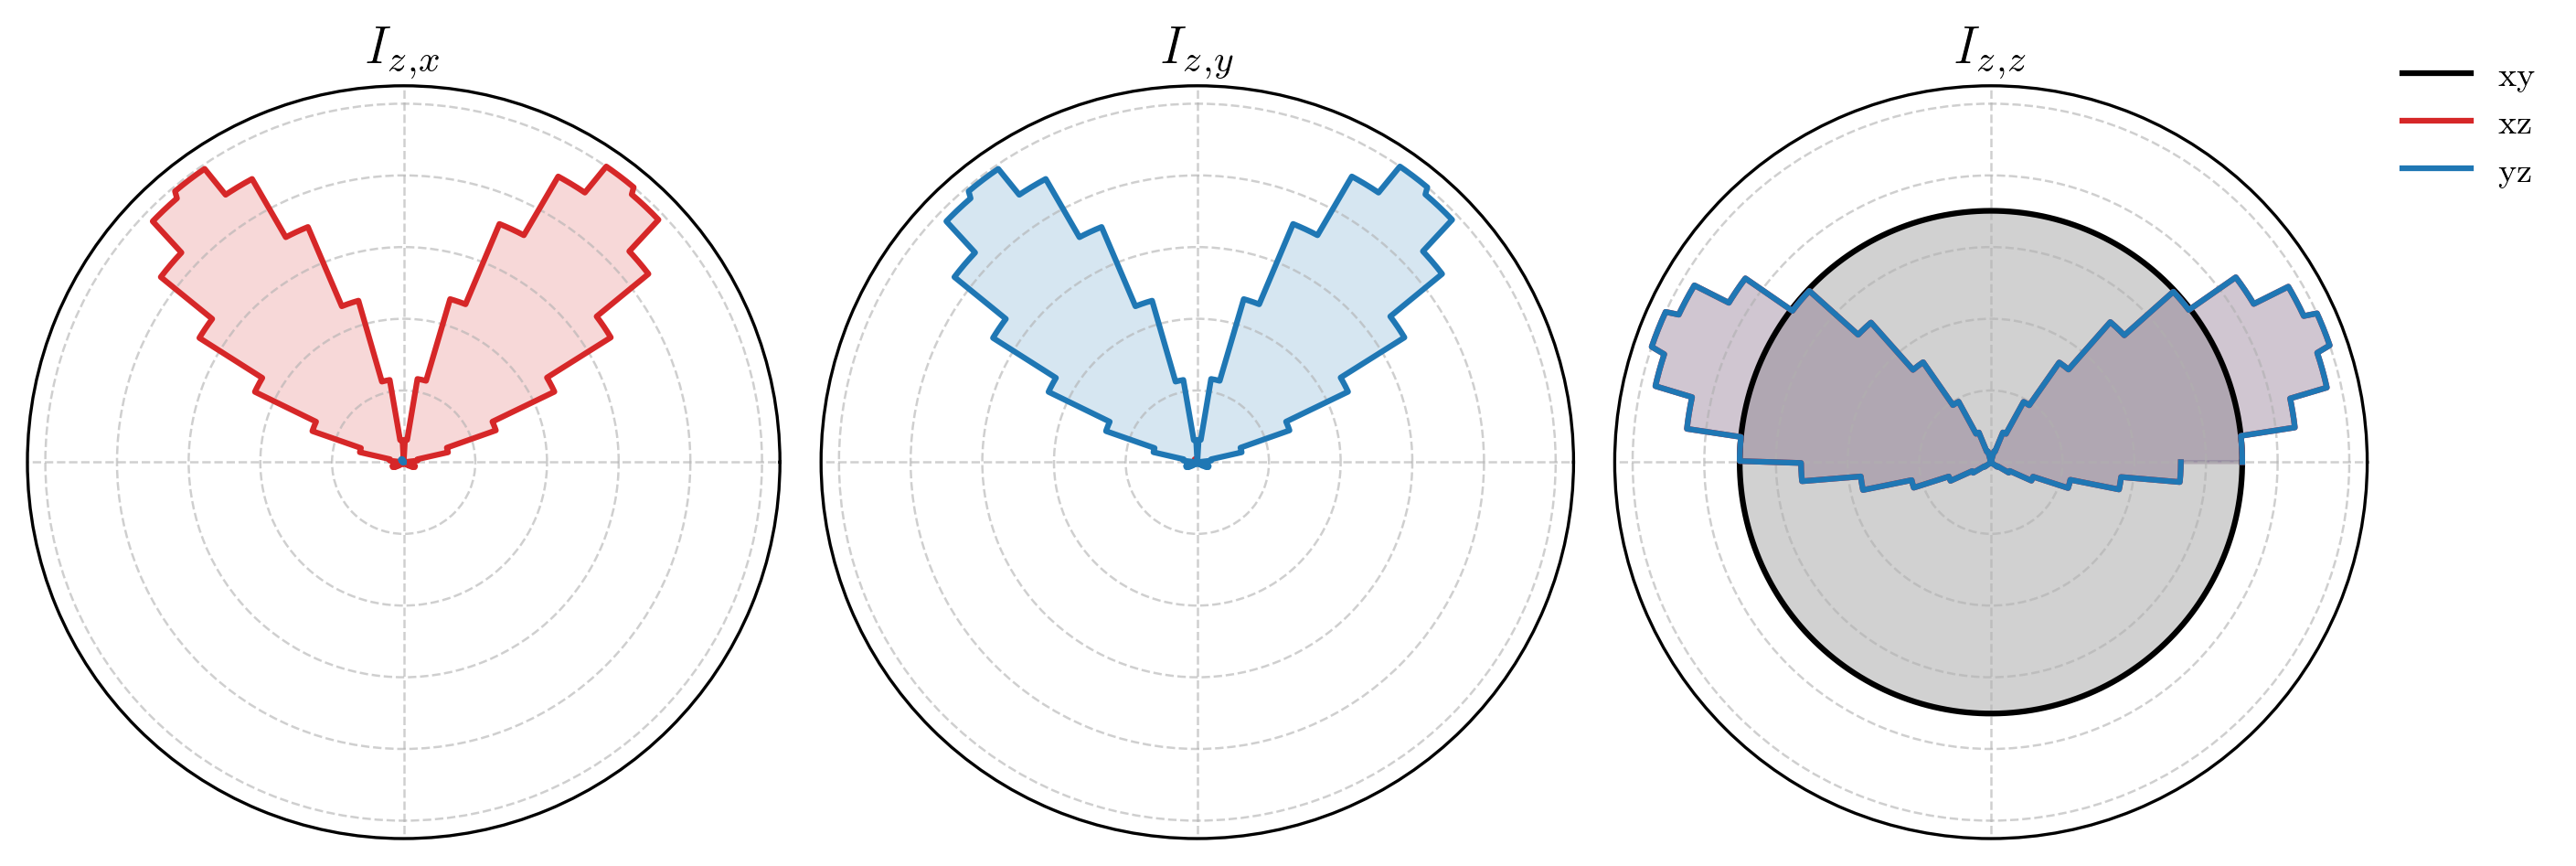

In [26]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"])

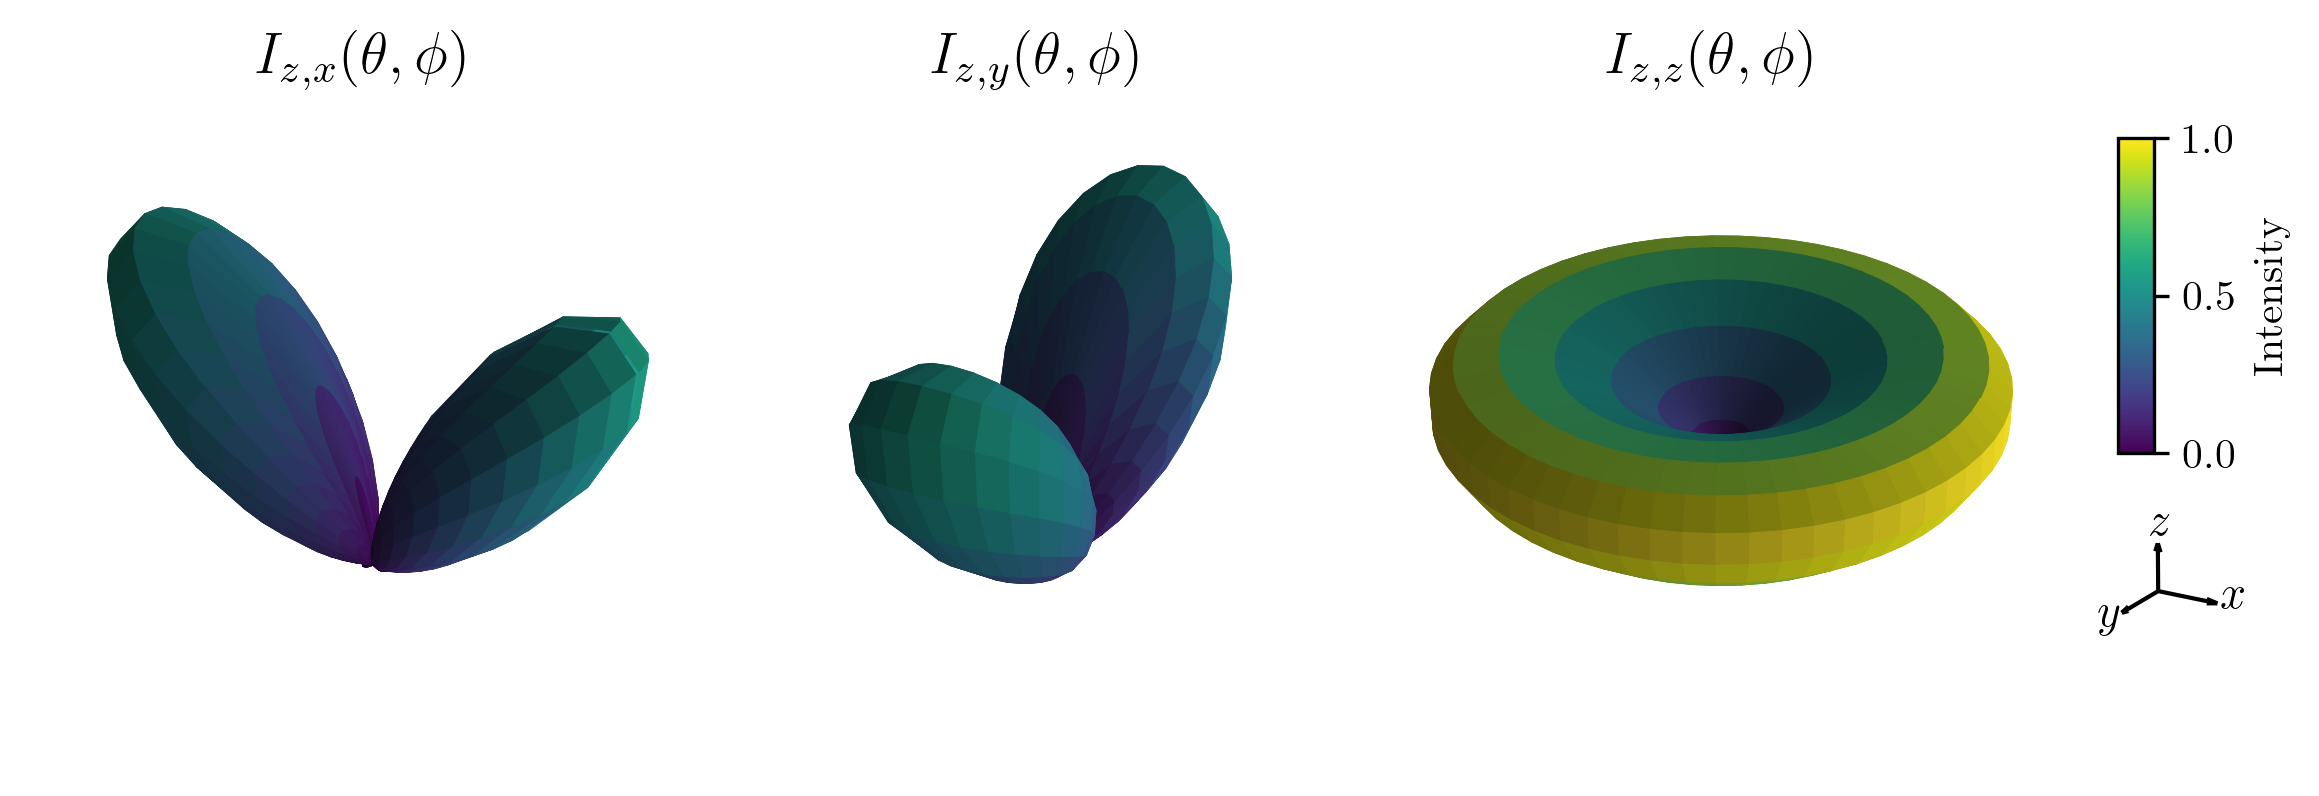

In [27]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], scale_list=[0.30, 0.30, 0.30])

## Total COM information patterns for the radial doughnut field

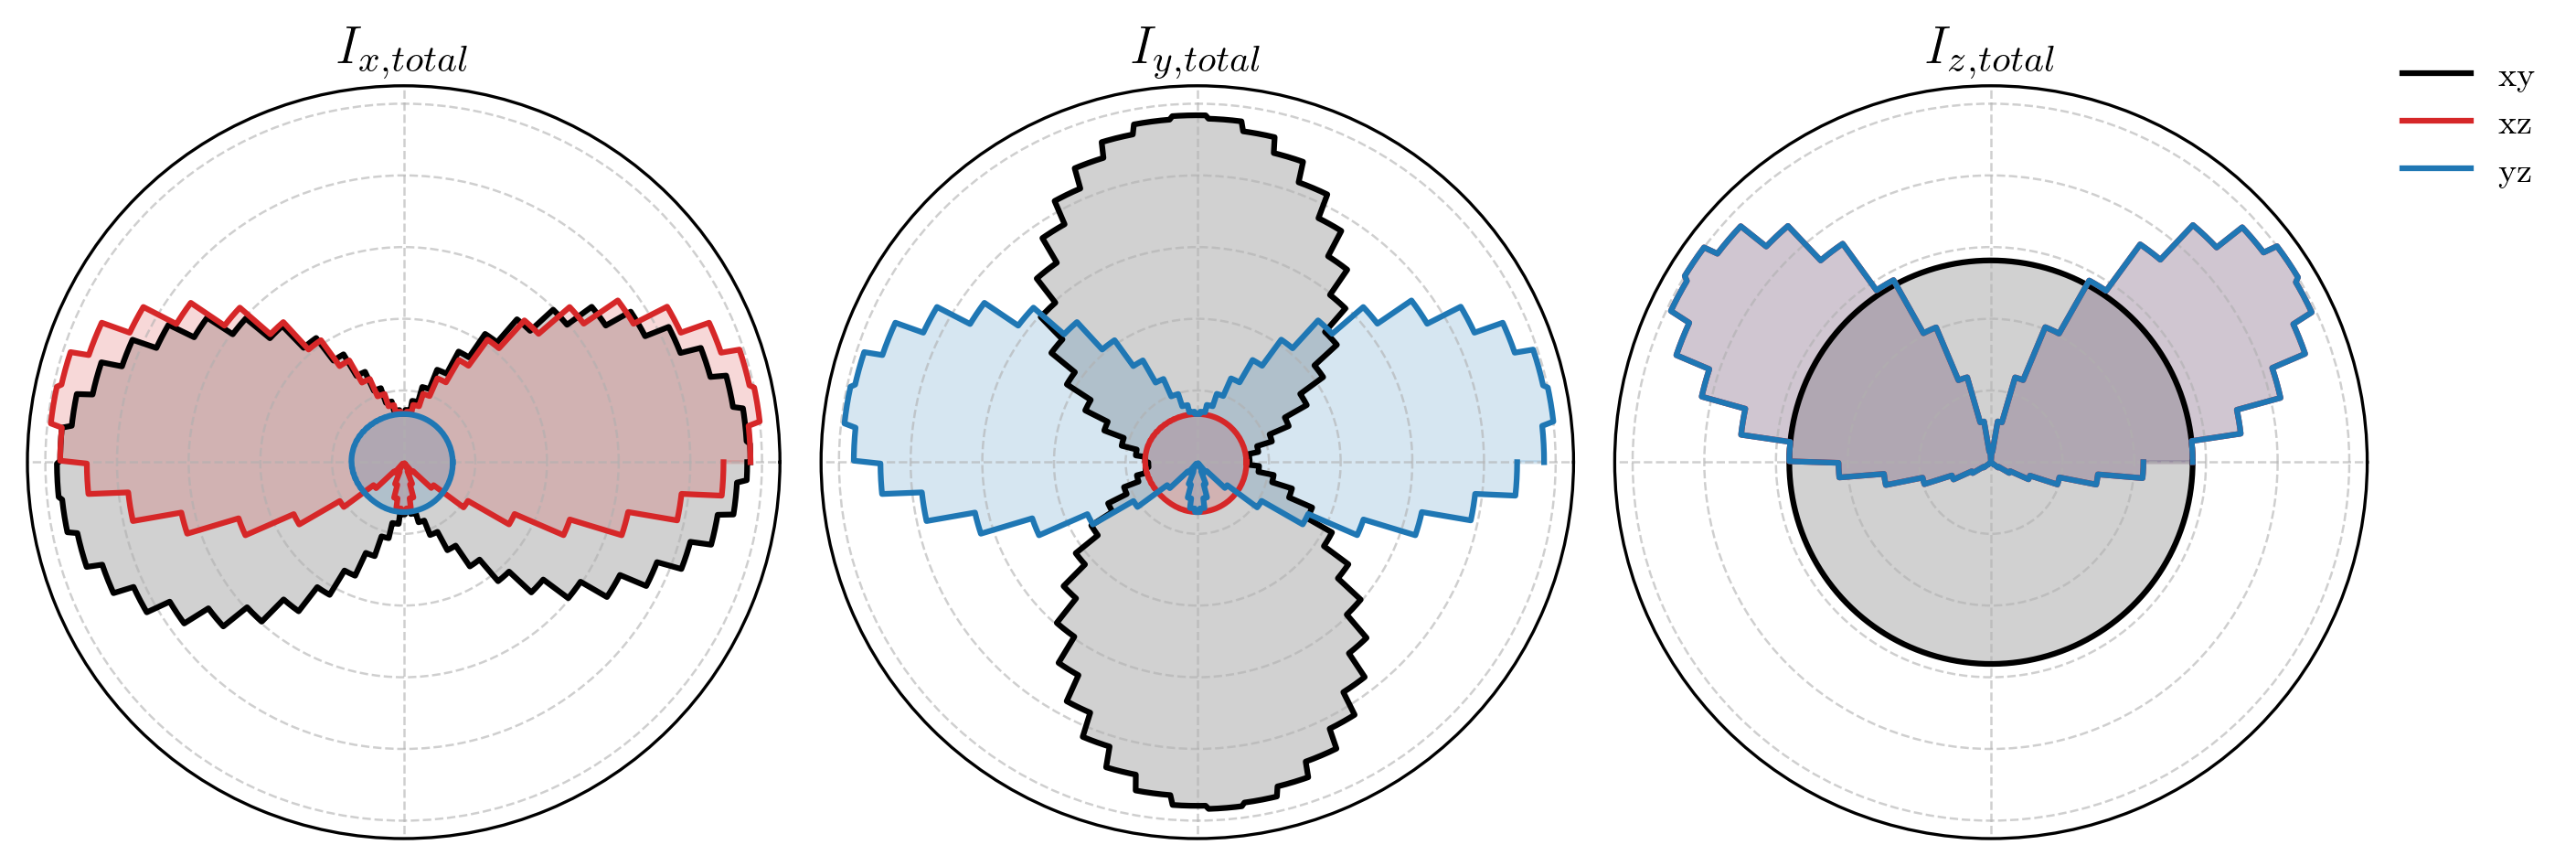

In [28]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"])

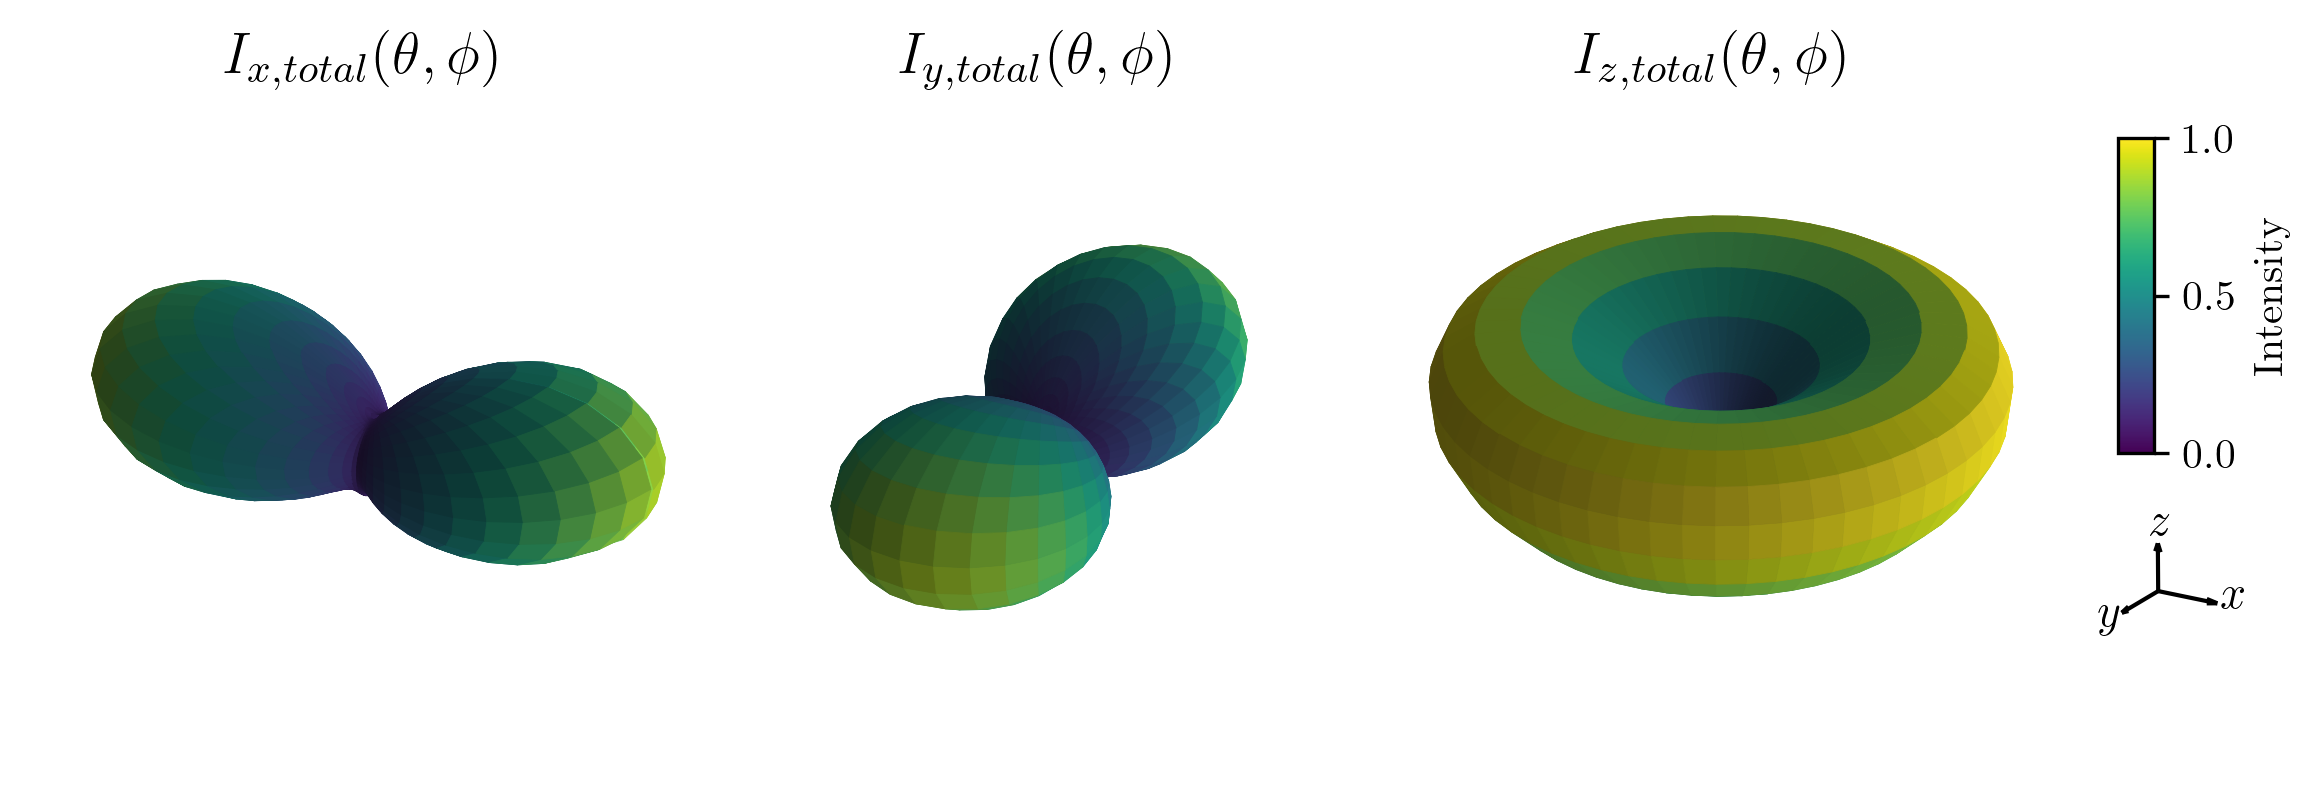

In [29]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], scale_list=[0.28, 0.28, 0.3])